In [ ]:
!git clone -b Lab_2_main https://github.com/Vasilisa-Kozlovskaya/SANS_itmo.git

Cloning into 'SANS_itmo'...
remote: Enumerating objects: 507, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 507 (delta 19), reused 25 (delta 11), pack-reused 411 (from 1)
Receiving objects: 100% (507/507), 14.88 MiB | 14.31 MiB/s, done.
Resolving deltas: 100% (225/225), done.


In [ ]:
import os
os.chdir('/content/SANS_itmo')

!ls

chekpoints  data       requirements.txt  src
configs     README.md  SANS_2.ipynb	 training


In [ ]:
# @title
!git pull origin Lab_2_main

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 5 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 414 bytes | 207.00 KiB/s, done.
From https://github.com/Vasilisa-Kozlovskaya/SANS_itmo
 * branch            Lab_2_main -> FETCH_HEAD
   989c4f1..65c0ffe  Lab_2_main -> origin/Lab_2_main
Updating 989c4f1..65c0ffe
Fast-forward
 src/models/model.py | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)


In [ ]:
import sys
sys.path.append('./src')

In [ ]:
# 1. Установка спец. библиотек
!pip install -U clearml pytorch-lightning omegaconf python-dotenv langdetect warcio tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 22.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 52.7 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=3d3630cbbf157af5e42f60cd988eec84664ba0b250340ef6e39f37cfcad12e98
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.67.3
    Uninstalling tqdm-4.67.3:
   

In [ ]:
%env CLEARML_WEB_HOST=https://app.clear.ml/
%env CLEARML_API_HOST=https://api.clear.ml
%env CLEARML_FILES_HOST=https://files.clear.ml
%env CLEARML_API_ACCESS_KEY=E4OE73FZ7O5OVN9FOKSZIFXG87136E
%env CLEARML_API_SECRET_KEY=D4XzHaRhKn7wohDjfI32rFdLcOky9wuajNlMTdTyRQOLNwotRce_rAoHBE8iFdyVwps

# 2. Настройка ClearML (нужно зайти на app.clear.ml, создать account и взять API Keys)
from clearml import Task
task = Task.init(project_name='LLM_Lab2', task_name='GPT_Training2.0')
task = task.close()

env: CLEARML_WEB_HOST=https://app.clear.ml/
env: CLEARML_API_HOST=https://api.clear.ml
env: CLEARML_FILES_HOST=https://files.clear.ml
env: CLEARML_API_ACCESS_KEY=E4OE73FZ7O5OVN9FOKSZIFXG87136E
env: CLEARML_API_SECRET_KEY=D4XzHaRhKn7wohDjfI32rFdLcOky9wuajNlMTdTyRQOLNwotRce_rAoHBE8iFdyVwps
ClearML Task: created new task id=44f022ccfdbe42fabb18a38f86a8ea71


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


2026-06-26 12:24:45,490 - clearml.Task - INFO - Storing jupyter notebook directly as code
ClearML results page: https://app.clear.ml/projects/4cb1d7c1d1c14f5ead58f644597b7087/experiments/44f022ccfdbe42fabb18a38f86a8ea71/output/log


In [ ]:
import pytorch_lightning as pl
from clearml import Task
from pytorch_lightning.loggers import CSVLogger # Запасной локальный логгер

# 1. Инициализируем задачу ClearML
# Это создаст задачу в панели ClearML и автоматически начнет перехватывать логи
task = Task.init(project_name="LLM_Lab", task_name="GPT_Training")

# 2. Вместо ClearMLLogger используем стандартный логгер Lightning (или TensorBoard)
# ClearML "магическим образом" перехватит логи из любого стандартного логгера
# (TensorBoard, CSV или даже обычные print/console logs).
logger = CSVLogger(save_dir="logs/", name="gpt_experiment")


ClearML Task: created new task id=aba8c484a57749e68647317d889125f6
ClearML results page: https://app.clear.ml/projects/773cb061bbc846c1bfe91ca33872efc6/experiments/aba8c484a57749e68647317d889125f6/output/log


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

def plot_metrics(log_dir="logs/"):
    exp_dir = os.path.join(log_dir, "gpt_experiment")
    if not os.path.exists(exp_dir):
        print("Папка с логами не найдена.")
        return

    versions = [d for d in os.listdir(exp_dir) if d.startswith("version_")]
    if not versions:
        print("Версии логов не найдены.")
        return

    latest_version = sorted(versions, key=lambda x: int(x.split("_")[1]))[-1]
    csv_path = os.path.join(exp_dir, latest_version, "metrics.csv")

    if not os.path.exists(csv_path):
        print(f"Файл metrics.csv еще не создан.")
        return

    df = pd.read_csv(csv_path)
    epochs = df.groupby('epoch').mean(numeric_only=True)

    fig, axs = plt.subplots(2, 2, figsize=(16, 10))

    # 1. LOSS
    train_loss_col = 'train_loss' if 'train_loss' in epochs.columns else 'train_loss_epoch'
    if train_loss_col in epochs.columns:
        axs[0, 0].plot(epochs.index, epochs[train_loss_col], label='Train Loss', marker='.')
    if 'val_loss' in epochs.columns:
        axs[0, 0].plot(epochs.index, epochs['val_loss'], label='Val Loss', marker='o')
    axs[0, 0].set_title('Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True, alpha=0.2)

    # 2. PERPLEXITY
    train_ppl_col = 'train_perplexity'
    if train_ppl_col in epochs.columns:
        axs[0, 1].plot(epochs.index, epochs[train_ppl_col], label='Train PPL', marker='.')
    if 'val_perplexity' in epochs.columns:
        axs[0, 1].plot(epochs.index, epochs['val_perplexity'], label='Val PPL', marker='o')
    axs[0, 1].set_title('Perplexity (Log Scale)')
    axs[0, 1].set_yscale('log')
    axs[0, 1].legend()
    axs[0, 1].grid(True, alpha=0.2)

    # 3. LOGITS (Исправлено: добавлена проверка наличия колонок)
    if 'logits_max' in df.columns and 'logits_min' in df.columns:
        logits_df = df.dropna(subset=['logits_max', 'logits_min'])
        if not logits_df.empty:
            axs[1, 0].plot(logits_df['logits_max'].values, label='Max', color='red', alpha=0.6)
            axs[1, 0].plot(logits_df['logits_min'].values, label='Min', color='blue', alpha=0.6)
            axs[1, 0].set_title('Logits Stability')
            axs[1, 0].legend()
    else:
        axs[1, 0].text(0.5, 0.5, 'Logits columns not found in CSV\n(Wait for more steps or check model.py)',
                       ha='center', va='center')
        axs[1, 0].set_title('Logits Stability')

    # 4. LEARNING RATE
    lr_cols = [c for c in df.columns if 'lr' in c.lower()]
    if lr_cols:
        lr_df = df.dropna(subset=[lr_cols[0]])
        axs[1, 1].plot(lr_df[lr_cols[0]].values, color='green')
        axs[1, 1].set_title('LR Schedule')

    plt.tight_layout()
    plt.show()

In [ ]:
import os
import sys
import torch

from src.tokenization.bpe import BpeTokenizer
from src.data.dataset import PackedDataset, pack_tokens

# 1. Инициализация и загрузка токенизатора из двух файлов
print("Загрузка токенизатора из vocab.json и merges.txt...")
bpe_tok = BpeTokenizer()
tokenizer_folder = "chekpoints" # Corrected folder path to be relative to current working directory

if os.path.exists(os.path.join(tokenizer_folder, "vocab.json")):
    bpe_tok.load(tokenizer_folder)
    print(f"Токенизатор загружен. Размер словаря: {bpe_tok.vocab_size}")
else:
    raise FileNotFoundError(f"Файлы токенизатора не найдены в {tokenizer_folder}")

from datasets import load_dataset
dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train", trust_remote_code=True)
wiki_texts = [item.strip() for item in dataset['text'] if len(item.strip()) > 20]

print("Токенизация и упаковка данных...")
all_tokens = pack_tokens(bpe_tok, wiki_texts, block_size=512)
packed_dataset = PackedDataset(all_tokens, block_size=512)


print(f"Успешно! Создано {len(packed_dataset)} блоков по 512 токенов.")

Загрузка токенизатора из vocab.json и merges.txt...
Токенизатор загружен. Размер словаря: 8000


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Salesforce/wikitext' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Salesforce/wikitext' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able t

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Токенизация и упаковка данных...
Успешно! Создано 6205 блоков по 512 токенов.


In [ ]:
import os
import torch
from omegaconf import OmegaConf
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
from torch.utils.data import DataLoader, random_split

from src.models.model import GPT
from src.data.dataset import CommonCrawlDataModule, TextDataset, PackedDataset

In [ ]:
# 1. Создаем конфиг
config = OmegaConf.create({
    "model": {
        "vocab_size": 8000,
        "n_embd": 384,
        "n_layer": 8,
        "n_head": 6,
        "block_size": 512,
        "dropout": 0.1
    },
    "training": {
        "batch_size": 16,
        "learning_rate": 6e-4,
        "weight_decay": 0.1,
        "warmup_steps": 800,
        "max_epochs": 40,
        "gradient_clip_val": 1.0
    }
})



In [ ]:
# 5. Коллбэки
checkpoint_callback = ModelCheckpoint(
    dirpath="checkpoints/",
    filename="gpt-best-{val_perplexity:.2f}",
    monitor="val_perplexity",
    mode="min",
    save_top_k=1
)
lr_monitor = LearningRateMonitor(logging_interval='step')

# 1. Разделяем данные (например, 90% обучение, 10% валидация)
train_size = int(0.9 * len(packed_dataset))
val_size = len(packed_dataset) - train_size

train_dataset, val_dataset = random_split(
    packed_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Размер обучающей выборки: {len(train_dataset)}")
print(f"Размер валидационной выборки: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=config.training.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.training.batch_size, shuffle=False)

# 2. РАССЧИТЫВАЕМ ШАГИ И ЗАПИСЫВАЕМ В КОНФИГ
steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * config.training.max_epochs

config.training.total_steps = total_steps # Это теперь попадет в configure_optimizers

print(f"Загружено блоков: {len(packed_dataset)}")
print(f"Шагов в одну эпоху: {steps_per_epoch}")
print(f"Всего шагов обучения: {total_steps}")


Размер обучающей выборки: 5584
Размер валидационной выборки: 621
Загружено блоков: 6205
Шагов в одну эпоху: 349
Всего шагов обучения: 13960


In [ ]:
# 4. Инициализация модели
model = GPT(config)

# 3. Запуск обучения (теперь с двумя лоадерами)
# В Trainer добавьте val_check_interval, чтобы чаще видеть графики в ClearML
trainer = Trainer(
    accumulate_grad_batches=4,
    precision="16-mixed",
    max_epochs=config.training.max_epochs,
    accelerator="auto",
    devices=1,
    logger=logger,
    callbacks=[checkpoint_callback, lr_monitor],
    gradient_clip_val=1.0,
    val_check_interval=0.5 # проверять валидацию дважды за эпоху
)


trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

Epoch 1/19 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 846/848 0:06:19 • 0:00:01 2.32it/s v_num: 1.000 val_loss: 7.848      
                                                                                 val_perplexity: 2566.280          
                                                                                 train_loss: 7.939                 

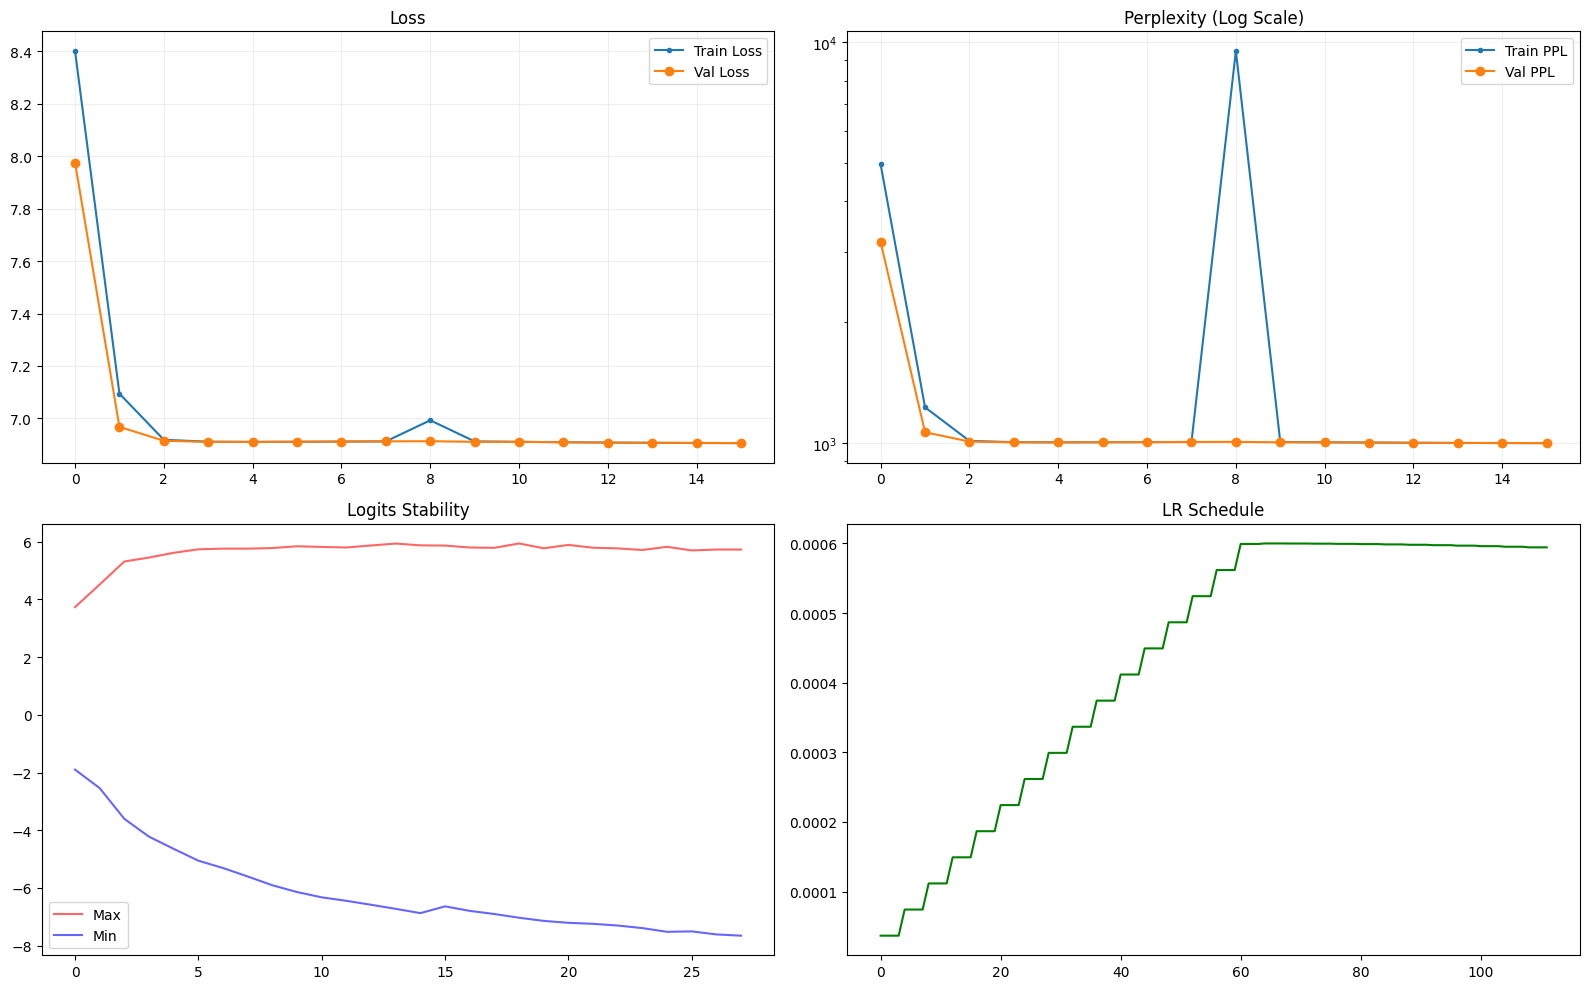

In [ ]:
plot_metrics()

In [ ]:
import torch

# 1. Настройка устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Подготовка модели
# Если ты только что обучил модель, она уже в переменной `model`
# Если ты перезагружал сессию, сначала загрузи её:
# model = GPT.load_from_checkpoint("checkpoints/gpt-best-XXXX.ckpt", config=config)

model.to(device)
model.eval()  # Обязательно: отключает Dropout и включает режим оценки

# 3. Текст для начала генерации
prompt_text = "The artificial intelligence "

# 4. Токенизация промпта
# Используем наш обученный BPE токенизатор
input_ids = torch.tensor(bpe_tok.encode(prompt_text)).unsqueeze(0).to(device)

# 5. Генерация
print(f"--- Промпт: {prompt_text} ---")
print("-" * 30)

with torch.no_grad(): # Отключаем расчет градиентов для скорости и экономии памяти
    # Параметры:
    # max_new_tokens: сколько слов/токенов добавить к промпту
    # temperature:
    #   < 1.0 — модель более консервативная и логичная
    #   > 1.0 — модель более "творческая" и хаотичная
    generated_indices = model.generate(
        input_ids,
        max_new_tokens=100,
        temperature=0.8
    )

# 6. Декодирование обратно в текст
# Берем результат (убираем размерность батча [0]) и переводим в список
output_text = bpe_tok.decode(generated_indices[0].tolist())

print(f"Результат генерации:\n{output_text}")